<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [14]</a>'.</span>

In [1]:
# --- parameters (patch_notebook_params.py) ---
MAX_EPOCHS = 2000
N_SAMPLES = 10           # run_metrics.py forces 50 for generative methods
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "results/metrics.csv"


In [2]:
# Parameters
MAX_EPOCHS = 2000
N_SAMPLES = 1
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "/Odyssey/private/m19beauc/4dvarnet-starter-devs/consistency/sbatch_submission/results/SSH_GF/FM_metrics_train.csv"


In [3]:
# --- epoch heartbeat (patch_notebook_params.py) ---
import pytorch_lightning as _pl

class EpochHeartbeat(_pl.Callback):
    """Prints one clear progress line every `every_n_epochs` epochs, so
    sbatch logs show training progress without the noise of a per-batch
    tqdm progress bar (which doesn't render well once redirected to a
    plain log file).    """

    def __init__(self, every_n_epochs: int = 1):
        self.every_n_epochs = every_n_epochs

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1
        if epoch % self.every_n_epochs != 0 and epoch != trainer.max_epochs:
            return
        parts = []
        for k, v in sorted(trainer.callback_metrics.items()):
            try:
                parts.append(f'{k}={float(v):.4f}')
            except (TypeError, ValueError):
                pass
        print(f'[progress] epoch {epoch}/{trainer.max_epochs} | ' + ' | '.join(parts), flush=True)


## Flow Matching — SSH Gulf Stream (NATL-GF)

Conditional Flow Matching (Heun ODE) applied to SSH data from the Gulf Stream region.
- Data: NATL-GF 5-nadir + SWOT, 0.05° native resolution, resize_factor=2 → 0.1°
- Window: 9 time steps, 128×128 patches

In [4]:
!nvidia-smi

Mon Aug 10 09:02:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                Off |   00000000:E3:00.0 Off |                    0 |
| N/A   84C    P0            275W /  400W |   64329MiB /  95830MiB |     99%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES

In [6]:
import math
import os
import zipfile
import glob
from dataclasses import dataclass
from typing import Optional, Tuple

import numpy as np
import xarray as xr
import pandas as pd
import torch
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torchinfo import summary

import sys
sys.path.append('../..')     # -> consistency/ (flowmatching_models_FM, spectral_utils)
sys.path.append('../../..')  # -> 4dvarnet-starter-devs/ (src)

from flowmatching_models_FM import (
    UNetFM, UNetFMConfig,
    LitFlowMatchingModel, LitFMConfig,
    LogScaleModel,
    heun_sample, euler_sample,
    neglogpdf, neglogcdf,
    sample_uniform_time, masked_average,
)

try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("properscoring not installed — CRPS disabled.")

## DataModule — SSH Gulf Stream (NATL-GF)

Load altimetry SSH data (5-nadir + SWOT observations), resize_factor=2 for 128×128 patches at ~0.1° resolution.

Norm stats (0.3047108663749711, 0.3879814586804132)


window_size (C) = 9
TrainingItem shapes -- input (y): (9, 128, 128), tgt (x): (9, 128, 128)


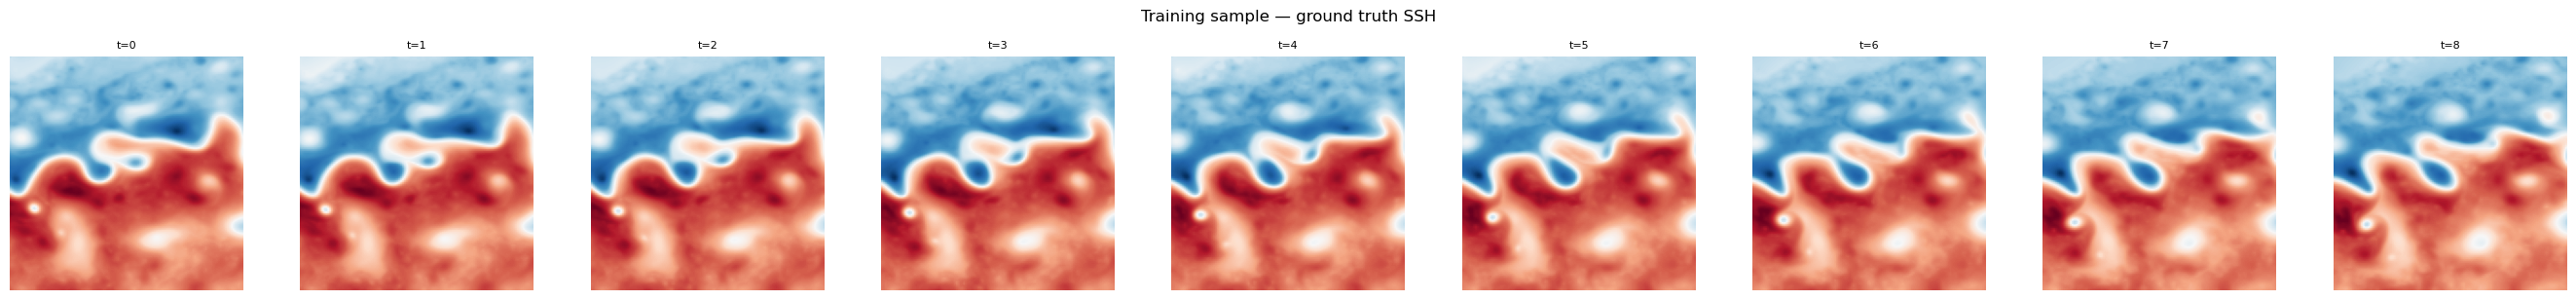

In [7]:
import pyinterp
import pyinterp.fill
import pyinterp.backends.xarray
from collections import namedtuple
from src.data_notebook import BaseDataModule

datadir = "../../../data"

TrainingItem = namedtuple('TrainingItem', ['input', 'tgt'])

def remove_nan(da):
    da["lon"] = da.lon.assign_attrs(units="degrees_east")
    da["lat"] = da.lat.assign_attrs(units="degrees_north")
    da.transpose("lon", "lat", "time")[:, :] = pyinterp.fill.gauss_seidel(
        pyinterp.backends.xarray.Grid3D(da)
    )[1]
    return da

def load_altimetry_data(path):
    ds = (
        xr.open_dataset(path)
        .load()
        .assign(
            input=lambda ds: ds.nadir_obs,
            tgt=lambda ds: remove_nan(ds.ssh),
        )
    )
    return (
        ds[[*TrainingItem._fields]]
        .transpose("time", "lat", "lon")
        .to_array()
    )

lon_min, lon_max = -66.3, -53.5
lat_min, lat_max =  31.7,  44.5

datamodule = BaseDataModule(
    input_da=load_altimetry_data(datadir + "/natl_gf_w_5nadirs_swot.nc"),
    domains={
        'train': {'time': slice('2013-02-24', '2013-09-30')},
        'val':   {'time': slice('2012-12-15', '2013-02-24')},
        'test':  {'time': slice('2012-10-01', '2012-12-20')},
    },
    xrds_kw={
        'patch_dims':    {'time': 9, 'lat': 128, 'lon': 128},
        'strides':       {'time': 1, 'lat': 128, 'lon': 128},
        'domain_limits': dict(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max)),
    },
    dl_kw={'batch_size': 1, 'num_workers': 1},
    grad=False,
    resize_factor=2,
)
datamodule.setup()

sample = datamodule.train_ds[0]
C = sample.tgt.shape[0]
print(f"window_size (C) = {C}")
print(f"TrainingItem shapes -- input (y): {sample.input.shape}, tgt (x): {sample.tgt.shape}")

fig, axes = plt.subplots(1, min(C, 9), figsize=(3 * min(C, 9), 3))
for t_idx, ax in enumerate(axes):
    im = ax.imshow(sample.tgt[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample — ground truth SSH", y=1.01)
plt.tight_layout()
plt.show()

### UNetFM — Velocity-prediction network

Input: `(x_t, y_obs, t)` → predicts the velocity field for the ODE flow from noise to clean signal.

In [8]:
C = datamodule.train_ds[0].tgt.shape[0]
cfg = UNetFMConfig(channels=C)
net = UNetFM(cfg)

summary(
    net,
    input_size=(
        (1, C, 128, 128),   # x_t  — noisy interpolant
        (1, C, 128, 128),   # y    — observations (NaN tolerated)
        (1,),               # t    — pseudo-time scalar
    ),
)

Layer (type:depth-idx)                        Output Shape              Param #
UNetFM                                        [1, 9, 128, 128]          --
├─Conv2d: 1-1                                 [1, 64, 128, 128]         15,616
├─TimeEmbedding: 1-2                          [1, 128, 1, 1]            64
│    └─Sequential: 2-1                        [1, 128, 1, 1]            --
│    │    └─Linear: 3-1                       [1, 512]                  66,048
│    │    └─SiLU: 3-2                         [1, 512]                  --
│    │    └─Linear: 3-3                       [1, 128]                  65,664
│    │    └─Rearrange: 3-4                    [1, 128, 1, 1]            --
├─ModuleList: 1-3                             --                        --
│    └─UNetBlock: 2-2                         [1, 64, 128, 128]         --
│    │    └─Sequential: 3-5                   [1, 64, 128, 128]         37,056
│    │    └─Sequential: 3-6                   [1, 64, 1, 1]             8,256
│

### LightningModule — LitFlowMatchingModel

Uses the linear interpolant of Flow Matching: `x_t = (1-t)*noise + t*x_clean`, loss = MSE on velocity.

In [9]:
# LitFlowMatchingModel is fully self-contained in flowmatching_models_FM.py.
help(LitFlowMatchingModel)

Help on class LitFlowMatchingModel in module flowmatching_models_FM:

class LitFlowMatchingModel(pytorch_lightning.core.module.LightningModule)
 |  LitFlowMatchingModel(network: 'UNetFM', config: 'LitFMConfig', n_log_scale_embedding: 'int' = 128) -> 'None'
 |  
 |  Flow Matching Lightning module for the SPDE dataset.
 |  
 |  Parameters
 |  ----------
 |  network     : ``UNetFM`` (student / live model)
 |  config      : ``LitFMConfig``
 |  n_log_scale_embedding : embedding dim for the ``LogScaleModel``
 |  
 |  Method resolution order:
 |      LitFlowMatchingModel
 |      pytorch_lightning.core.module.LightningModule
 |      lightning_fabric.utilities.device_dtype_mixin._DeviceDtypeModuleMixin
 |      pytorch_lightning.core.mixins.hparams_mixin.HyperparametersMixin
 |      pytorch_lightning.core.hooks.ModelHooks
 |      pytorch_lightning.core.hooks.DataHooks
 |      pytorch_lightning.core.hooks.CheckpointHooks
 |      torch.nn.modules.module.Module
 |      builtins.object
 |  
 |  Meth

## Training

In [10]:
def is_valid_checkpoint(path: str) -> bool:
    try:
        import zipfile
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False

def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last) and is_valid_checkpoint(last):
        print(f"Valid checkpoint: {last}")
        return last
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt")) if "last" not in p],
        key=lambda p: float(p.split("train_loss=")[-1].replace(".ckpt", ""))
        if "train_loss=" in p else float("inf"),
    )
    for p in all_ckpts:
        if is_valid_checkpoint(p):
            print(f"Valid checkpoint: {p}")
            return p
    print("No valid checkpoint found. Starting from scratch.")
    return None

C = datamodule.train_ds[0].tgt.shape[0]

LOG_DIR     = "logs_FM_ssh_gf"
CKPT_DIR    = os.path.join(LOG_DIR, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, "best_model")

# RESET_TRAINING set by the parameters cell above
if RESET_TRAINING:
    import shutil
    for d in [CKPT_DIR, MODEL_PATH]:
        if os.path.exists(d):
            shutil.rmtree(d)
    resume_ckpt = None
    print("RESET_TRAINING=True -- starting from scratch")
else:
    resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

network  = UNetFM(UNetFMConfig(channels=C))
lit_fm   = LitFlowMatchingModel(
    network=network,
    config=LitFMConfig(lr_scheduler_iters=1000, eval_n_steps=20),
)

trainer = Trainer(enable_progress_bar=False, 
    accelerator="gpu",
    max_epochs=MAX_EPOCHS,
    accumulate_grad_batches=4,
    precision="16-mixed",
    log_every_n_steps=1,
    logger=TensorBoardLogger(".", name=LOG_DIR, version=""),
    callbacks=[
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath=CKPT_DIR,
            monitor="train_loss",
            save_top_k=3,
            save_last=True,
            filename="{epoch:03d}-{step}-{train_loss:.4f}",
        ),
    ],
)

seed_everything(42)
trainer.callbacks.append(EpochHeartbeat(every_n_epochs=1))
trainer.fit(lit_fm, datamodule, ckpt_path=resume_ckpt)

ema_net = lit_fm.ema_model.module
ema_net.save_pretrained(MODEL_PATH)
print(f"EMA model saved to: {MODEL_PATH}")

Valid checkpoint: logs_FM_ssh_gf/checkpoints/last.ckpt


/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:168: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /Odyssey/private/m19beauc/conda_envs/4dvarnet-starte ...
  rank_zero_warn(
Using 16bit Automatic Mixed Precision (AMP)


/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


IPU available: False, using: 0 IPUs


...

[Epoch 1998]  Val RMSE (20 Heun steps, EMA) = 0.1544


[progress] epoch 2000/2000 | train_loss=-1.7045 | train_loss_epoch=-1.7045 | train_loss_step=-2.0751 | val_rmse_ema=0.1544


[Epoch 1999]  Val RMSE (20 Heun steps, EMA) = 0.1566


`Trainer.fit` stopped: `max_epochs=2000` reached.


EMA model saved to: logs_FM_ssh_gf/best_model


## Sampling & Evaluation

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float32

MODEL_PATH = os.path.join("logs_FM_ssh_gf", "best_model")

ema_unet = UNetFM.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
print(f"EMA UNetFM loaded from {MODEL_PATH}")
print(f"  Params : {sum(p.numel() for p in ema_unet.parameters()):,}")

EMA UNetFM loaded from logs_FM_ssh_gf/best_model
  Params : 32,279,049


### Test Batch

In [12]:
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))

x_gt  = batch.tgt.to(device=device, dtype=dtype)
y_obs = batch.input.to(device=device, dtype=dtype)

B, C, H, W = x_gt.shape
print(f"Test batch  x_gt:{tuple(x_gt.shape)}  y_obs:{tuple(y_obs.shape)}")

m_norm, s_norm = datamodule.norm_stats()

[rank: 0] Global seed set to 42


Test batch  x_gt:(1, 9, 128, 128)  y_obs:(1, 9, 128, 128)


### Ensemble Generation (N_SAMPLES members)

In [13]:
# N_SAMPLES set by the parameters cell above
N_STEPS   = 20   # Heun ODE steps

samples = []

with torch.no_grad():
    for s in range(N_SAMPLES):
        noise = torch.randn_like(x_gt)
        x_pred, _ = heun_sample(ema_unet, noise, y_obs, n_steps=N_STEPS)
        samples.append(x_pred.cpu())
        print(f"  member {s+1}/{N_SAMPLES} done", end="\r")

samples = torch.stack(samples, dim=0)   # (N_SAMPLES, B, C, H, W)
print(f"\nEnsemble tensor: {tuple(samples.shape)}")

ens_mean = samples.mean(0)              # (B, C, H, W)
ens_std  = samples.std(0)               # (B, C, H, W)

_b = 0
ens_mean_1 = ens_mean[_b]   # (C, H, W)
ens_std_1  = ens_std[_b]    # (C, H, W)
ensemble_1 = samples[:, _b] # (N, C, H, W)

  member 1/1 done
Ensemble tensor: (1, 1, 9, 128, 128)


/tmp/ipykernel_2524755/3626905768.py:17: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1879.)
  ens_std  = samples.std(0)               # (B, C, H, W)


### Publication Figures — comparison & uncertainty

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [14]:
from matplotlib.gridspec import GridSpec

FIG_TAG = 'FM_ssh_gf'
FIG_DIR = os.path.join('figures', FIG_TAG)
os.makedirs(FIG_DIR, exist_ok=True)

obs_phys  = batch.input[_b].float().cpu().numpy() * s_norm + m_norm
gt_phys   = batch.tgt[_b].float().cpu().numpy()   * s_norm + m_norm
mean_phys = ens_mean_1.float().cpu().numpy() * s_norm + m_norm
std_phys  = ens_std_1.float().cpu().numpy()  * s_norm
mbr0_phys = ensemble_1[0].float().cpu().numpy() * s_norm + m_norm
mbr1_phys = ensemble_1[1].float().cpu().numpy() * s_norm + m_norm

vmax_f = float(np.nanpercentile(np.abs(gt_phys), 99))
vmin_f = -vmax_f
vmax_s = float(np.nanpercentile(std_phys, 99))

cmap_f = plt.cm.RdBu_r.copy(); cmap_f.set_bad('lightgray')
cmap_s = plt.cm.Reds.copy();   cmap_s.set_bad('lightgray')

def _save_strip(data, filename, vmin, vmax, cmap):
    FW, FH, CB_H = 2.0, 2.0, 0.28
    fig_w = C * FW
    fig_h = FH + CB_H + 0.06
    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = GridSpec(2, C, left=0.01, right=0.99, top=0.99, bottom=0.01,
                  height_ratios=[FH, CB_H], hspace=0.06, wspace=0.03)
    for c in range(C):
        ax = fig.add_subplot(gs[0, c])
        ax.imshow(data[c], origin='lower', cmap=cmap,
                  vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.axis('off')
    ax_cb = fig.add_subplot(gs[1, :])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cb = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
    cb.ax.tick_params(labelsize=9)
    fpath = os.path.join(FIG_DIR, f'{filename}.png')
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    print(f'  Saved: {fpath}')
    plt.show()

for data, fname, vmin, vmax, cmap in [
    (obs_phys,  f'{FIG_TAG}_obs',        vmin_f, vmax_f, cmap_f),
    (gt_phys,   f'{FIG_TAG}_gt',         vmin_f, vmax_f, cmap_f),
    (mean_phys, f'{FIG_TAG}_fm_mean',    vmin_f, vmax_f, cmap_f),
    (std_phys,  f'{FIG_TAG}_fm_spread',  0.0,    vmax_s, cmap_s),
    (mbr0_phys, f'{FIG_TAG}_member0',    vmin_f, vmax_f, cmap_f),
    (mbr1_phys, f'{FIG_TAG}_member1',    vmin_f, vmax_f, cmap_f),
]:
    _save_strip(data, fname, vmin, vmax, cmap)

IndexError: index 1 is out of bounds for dimension 0 with size 1

### ODE Transport Process — Heun trajectory

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

T_CH   = C // 2
N_SHOW = 10

N_VIZ_STEPS = 20
torch.manual_seed(42)
noise_traj = torch.randn(1, C, H, W, device=device, dtype=dtype)
y_traj     = y_obs[0:1]

with torch.no_grad():
    _, trajectory = heun_sample(ema_unet, noise_traj, y_traj, n_steps=N_VIZ_STEPS)

transport_n = torch.stack(trajectory, dim=0)[:, 0, T_CH, :, :].float().cpu().numpy()
transport_p = transport_n * s_norm + m_norm

nfr = transport_p.shape[0]
stride = max(1, nfr // N_SHOW)
idx_show = list(range(0, nfr, stride))
if (nfr - 1) not in idx_show:
    idx_show.append(nfr - 1)
frames = transport_p[idx_show]
nf = len(frames)

FW, FH   = 2.4, 2.4
ARR_H    = 0.28
GAP_1    = 0.14
CB_H     = 0.26
GAP_2    = 0.16

fig_w = nf * FW
fig_h = ARR_H + GAP_1 + CB_H + GAP_2 + FH

arr_y_f   = (ARR_H / 2) / fig_h
cb_bot_f  = (ARR_H + GAP_1) / fig_h
cb_h_f    = CB_H / fig_h
img_bot_f = (ARR_H + GAP_1 + CB_H + GAP_2) / fig_h

fig = plt.figure(figsize=(fig_w, fig_h))

gs = GridSpec(1, nf, left=0.01, right=0.99,
              top=0.99, bottom=img_bot_f,
              hspace=0, wspace=0.02)

vmax_t = float(np.nanpercentile(np.abs(transport_p), 99))
cmap_t = plt.cm.RdBu_r
for i in range(nf):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(frames[i], origin='lower', cmap=cmap_t,
              vmin=-vmax_t, vmax=vmax_t, interpolation='nearest')
    ax.axis('off')

cb_ax = fig.add_axes([0.15, cb_bot_f, 0.70, cb_h_f])
sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=plt.Normalize(-vmax_t, vmax_t))
sm.set_array([])
cb = fig.colorbar(sm, cax=cb_ax, orientation='horizontal')
cb.set_label('SSH (physical units)', fontsize=24, fontweight='bold')
cb.ax.tick_params(labelsize=20)

fig.add_artist(mpatches.FancyArrowPatch(
    (0.04, 1+arr_y_f), (0.96, 1+arr_y_f),
    transform=fig.transFigure, arrowstyle='-|>',
    color='black', mutation_scale=32, linewidth=1.5,
))
fig.text(0.02, 1+arr_y_f, 'noise', va='bottom', ha='left',  fontsize=24, color='steelblue')
fig.text(0.98, 1+arr_y_f, 'clean', va='bottom', ha='right', fontsize=24, color='tomato')
fig.text(0.50, 1+arr_y_f, 'ODE time (Heun)', va='bottom', ha='center', fontsize=24)

fpath = os.path.join(FIG_DIR, f'{FIG_TAG}_transport.png')
fig.savefig(fpath, dpi=200, bbox_inches='tight')
print(f'  Saved: {fpath}')
plt.show()

## Metrics — FM vs GT

Evaluation at the **centre of the assimilation window**.

| Metric | Description |
|---|---|
| **Score** | $1 - \text{RMSE}/\sigma_{\text{GT}}$ |
| **RMSE** | Root Mean Square Error vs GT |
| **sigma_pred** | Std of the ensemble mean |
| **CRPS** | Continuous Ranked Probability Score at observed pixels |
| **lambda_x** | Resolved scale: wavelength where spectral score = 0.5 |

In [ ]:
import sys
sys.path.append('../..')
from spectral_utils import radial_psd_2d, psd_spectral_score, resolved_scale

DX = 0.1   # pixel spacing in degrees (0.1° resolution)

# ── Full test-set evaluation ─────────────────────────────────────────────
# Loops over EVERY batch of datamodule.test_dataloader() (not just the first
# one used for the illustrative figures above) and EVERY timestep of the
# assimilation window (not just T_EVAL=C//2). This is the expensive part
# (N_SAMPLES x n_test_batches Heun integrations) -- N_SAMPLES was reduced
# from 50 to 20 in methods.yaml specifically to keep a full-test-set pass
# affordable. SSH_GF is a continuous z-scored field, so unlike SIC there is
# no MIZ-style domain restriction -- metrics are aggregated over the whole
# spatial domain.
_all = {'score': [], 'rmse': [], 'sigma_gt': [], 'sigma_pred': [], 'crps': [], 'lambda_x': []}
_n_pairs = 0

seed_everything(42)
for _tb in datamodule.test_dataloader():
    _x_gt_b = _tb.tgt.to(device=device, dtype=dtype)      # (B, C, H, W)
    _y_b    = _tb.input.to(device=device, dtype=dtype)     # (B, C, H, W)
    _Bb, _Cb, _Hb, _Wb = _x_gt_b.shape
    _valid_b   = ~torch.isnan(_x_gt_b)
    _obsmask_b = ~torch.isnan(_y_b)

    with torch.no_grad():
        _members = []
        for _ in range(N_SAMPLES):
            _noise = torch.randn_like(_x_gt_b)
            _x_pred, _ = heun_sample(ema_unet, _noise, _y_b, n_steps=N_STEPS)
            _members.append(_x_pred.cpu())
    _ens_b = torch.stack(_members, dim=0)         # (N, B, C, H, W) normalised
    _ens_mean_b = _ens_b.mean(0)                   # (B, C, H, W)

    for _bi in range(_Bb):
        for _t in range(_Cb):
            _valid_t = _valid_b[_bi, _t].cpu().numpy()
            if _valid_t.sum() < 10:
                continue
            _gt_p   = _x_gt_b[_bi, _t].float().cpu().numpy() * s_norm + m_norm
            _mean_p = _ens_mean_b[_bi, _t].float().numpy()    * s_norm + m_norm
            _ens_p  = _ens_b[:, _bi, _t].float().numpy()      * s_norm + m_norm

            _gt_v, _pred_v = _gt_p[_valid_t], _mean_p[_valid_t]
            _sigma = float(np.std(_gt_v))
            if _sigma <= 0:
                continue
            _rmse  = float(np.sqrt(np.mean((_pred_v - _gt_v) ** 2)))
            _score = 1.0 - _rmse / _sigma
            _sigma_pred = float(np.std(_pred_v))

            _gt_f   = np.nan_to_num(_gt_p,   nan=0.0)
            _pred_f = np.nan_to_num(_mean_p, nan=0.0)
            _wl, _, _, _spec = psd_spectral_score(_pred_f, _gt_f, dx=DX)
            _lam = resolved_scale(_wl, _spec, threshold=0.5)

            _crps_val = np.nan
            if HAS_PROPERSCORING:
                _obs_t  = _obsmask_b[_bi, _t].cpu().numpy()
                _obs_ij = np.argwhere(_valid_t & _obs_t)
                if len(_obs_ij) > 0:
                    _stride = max(1, len(_obs_ij) // 50)   # subsample -- CRPS is O(n) Python loop
                    _crps_val = float(np.mean([
                        crps_ensemble(float(_gt_p[i, j]), _ens_p[:, i, j])
                        for i, j in _obs_ij[::_stride]
                    ]))

            _all['score'].append(_score)
            _all['rmse'].append(_rmse)
            _all['sigma_gt'].append(_sigma)
            _all['sigma_pred'].append(_sigma_pred)
            _all['crps'].append(_crps_val)
            _all['lambda_x'].append(_lam)
            _n_pairs += 1

print(f"Evaluated {_n_pairs} (test sample, timestep) pairs across the full test set")

def _agg(vals):
    a = np.asarray(vals, dtype=float)
    a = a[~np.isnan(a)]
    return (float(np.mean(a)), float(np.std(a))) if len(a) else (np.nan, np.nan)

_score_m, _score_s = _agg(_all['score'])
_rmse_m, _rmse_s = _agg(_all['rmse'])
_sgt_m, _sgt_s = _agg(_all['sigma_gt'])
_spr_m, _spr_s = _agg(_all['sigma_pred'])
_crps_m, _crps_s = _agg(_all['crps'])
_lam_m, _lam_s = _agg(_all['lambda_x'])

row_fm = {
    'Method'    : 'FM (ens. mean, full test set)',
    'Score'     : f'{_score_m:.3f} ± {_score_s:.3f}',
    'RMSE'      : f'{_rmse_m:.4f} ± {_rmse_s:.4f}',
    'sigma_GT'  : f'{_sgt_m:.4f} ± {_sgt_s:.4f}',
    'sigma_pred': f'{_spr_m:.4f} ± {_spr_s:.4f}',
    'CRPS'      : f'{_crps_m:.4f} ± {_crps_s:.4f}' if not np.isnan(_crps_m) else '--',
    'lambda_x'  : f'{_lam_m:.2f} ± {_lam_s:.2f}' if not np.isnan(_lam_m) else '?',
}
df_metrics = pd.DataFrame([row_fm]).set_index('Method')
df_metrics.columns = ['Score','RMSE','sigma_GT','sigma_pred','CRPS','lambda_x [deg]']
print(f'\n## Metrics -- full test set (whole domain), n={_n_pairs} (sample,t) pairs\n')
display(df_metrics)

# ── Illustrative PSD plot (single example, T_EVAL=C//2 of the first test
# batch, same one used by the figures above) -- qualitative check only, NOT
# the quantitative table (that's df_metrics above, full test set now).
T_EVAL = C // 2
gt_p_ex   = batch.tgt[_b, T_EVAL].float().cpu().numpy() * s_norm + m_norm
mean_p_ex = ens_mean_1[T_EVAL].float().cpu().numpy()    * s_norm + m_norm

wl_fm, _, _, spec_fm = psd_spectral_score(mean_p_ex, gt_p_ex, dx=DX)
_, psd_gt_r, psd_err_fm, _ = psd_spectral_score(mean_p_ex, gt_p_ex, dx=DX)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
valid = np.isfinite(wl_fm) & np.isfinite(psd_gt_r) & (psd_gt_r > 0)
ax.semilogy(wl_fm[valid], psd_gt_r[valid],  'k-',   lw=2,   label='GT')
valid_err = np.isfinite(wl_fm) & np.isfinite(psd_err_fm) & (psd_err_fm > 0)
ax.semilogy(wl_fm[valid_err], psd_err_fm[valid_err], 'C0--', lw=1.5, label='FM error')
ax.set_xlabel('Wavelength [deg]')
ax.set_ylabel('PSD')
ax.set_title(f'PSD -- GT & error (illustrative, t={T_EVAL})')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
lambda_x_fm = resolved_scale(wl_fm, spec_fm)
lbl_fm = f'FM (lambda_x={lambda_x_fm:.2f} deg)' if not np.isnan(lambda_x_fm) else 'FM'
valid_fm = np.isfinite(wl_fm) & np.isfinite(spec_fm)
ax.plot(wl_fm[valid_fm], spec_fm[valid_fm], 'C0-', lw=2, label=lbl_fm)
ax.axhline(0.5, color='gray', lw=1.2, ls='--', label='threshold 0.5')
if not np.isnan(lambda_x_fm):
    ax.axvline(lambda_x_fm, color='C0', lw=1, ls=':')
ax.set_xlabel('Wavelength [deg]')
ax.set_ylabel('Spectral score')
ax.set_title('Score PSD = 1 - PSD(err) / PSD(GT) (illustrative)')
ax.set_ylim(-0.3, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# --- metrics serialization (patch_notebook_params.py) ---
import os
os.makedirs(os.path.dirname(METRICS_CSV) or '.', exist_ok=True)
_df_out = df_metrics.reset_index() if df_metrics.index.name == 'Method' else df_metrics
_df_out.to_csv(METRICS_CSV, index=False)
print(f'Metrics written to {METRICS_CSV}')
